In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# قراءة البيانات النظيفة من فولدر preprocessing
df = pd.read_csv('preprocessing/cleaned_fordgobike_data.csv')

# عرض أول 5 صفوف للتأكد إن الداتا اتقرت صح
display(df.head())

,duration_sec,start_time,end_time,start_station_id,start_station_name,start_station_latitude,start_station_longitude,end_station_id,end_station_name,end_station_latitude,...,start_time_td,end_time_td,start_minute,end_minute,member_age,duration_min,weekday,is_weekend,age_group,user_type_encoded
0,1585,NaN,2026-09-10 20:44:06,7.0,Frank H Ogawa Plaza,37.804562,-122.271738,222.0,10th Ave at E 15th St,37.792714,...,NaN,NaN,NaN,NaN,45.0,26.416667,NaN,False,31-45,1
1,1793,NaN,2026-09-10 19:51:48,93.0,4th St at Mission Bay Blvd S,37.770407,-122.391198,323.0,Broadway at Kearny,37.798014,...,NaN,NaN,NaN,NaN,60.0,29.883333,NaN,False,46-60,1
2,1147,NaN,2026-09-10 14:42:36,300.0,Palm St at Willow St,37.317298,-121.884995,312.0,San Jose Diridon Station,37.329732,...,NaN,NaN,NaN,NaN,36.0,19.116667,NaN,False,31-45,1
3,1615,NaN,2026-09-10 08:02:48,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,NaN,NaN,NaN,NaN,30.0,26.916667,NaN,False,18-30,1
4,1570,NaN,2026-09-10 07:59:42,10.0,Washington St at Kearny St,37.795393,-122.404770,127.0,Valencia St at 21st St,37.756708,...,NaN,NaN,NaN,NaN,31.0,26.166667,NaN,False,31-45,1


In [3]:
%pip install seaborn


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Number of missing values in 'start_time': 108386


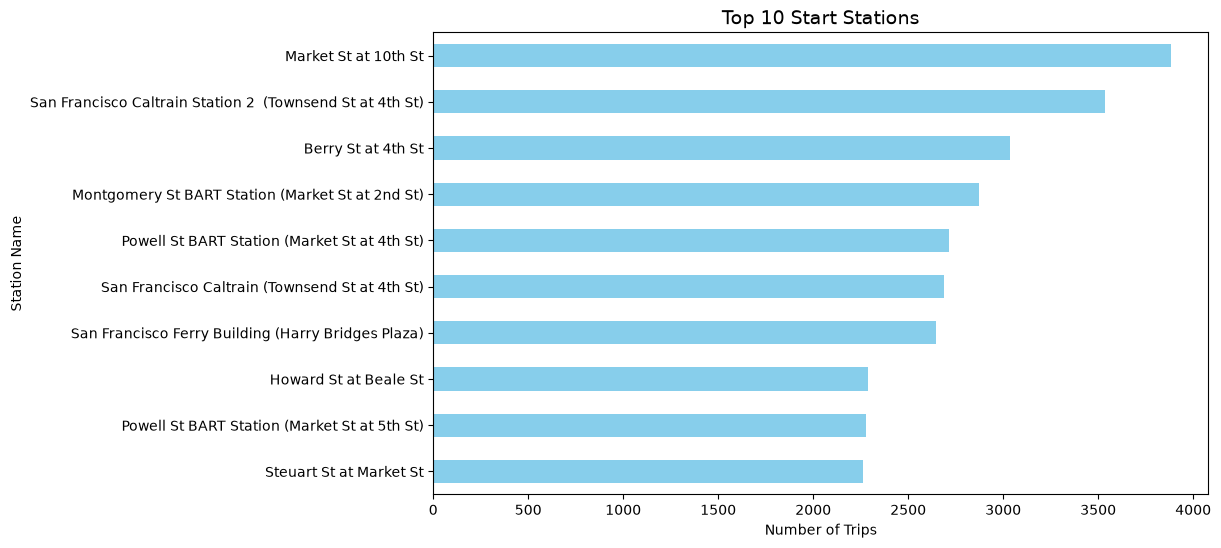

C:\Users\abdok\AppData\Local\Temp\ipykernel_28960\1802876350.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='hour', palette='viridis')


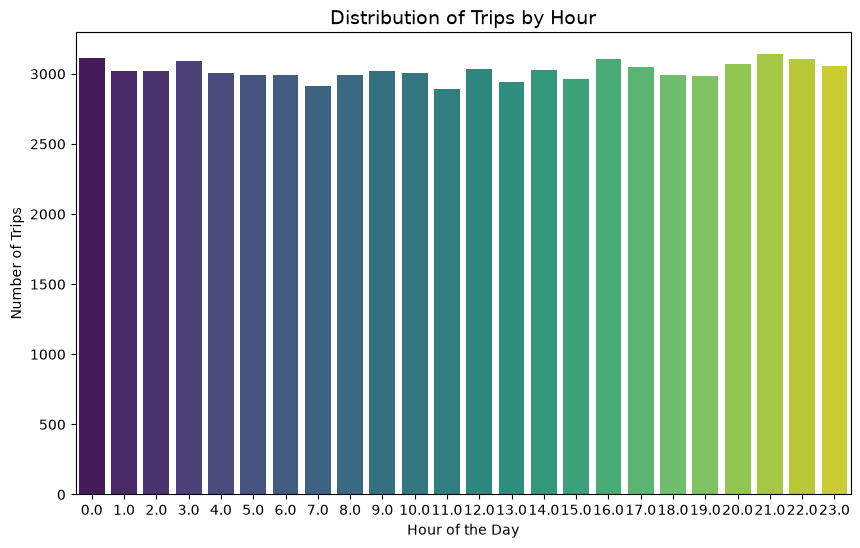

In [5]:
# 1. التأكد من حجم المشكلة في عمود وقت البداية
missing_start = df['start_time'].isnull().sum()
print(f"Number of missing values in 'start_time': {missing_start}")

# 2. تجهيز عمود end_time كبديل لاستخراج (الساعة - واليوم)
# تحويل العمود لصيغة وقت وتاريخ
df['end_time'] = pd.to_datetime(df['end_time'], errors='coerce')

# استخراج الساعة واليوم
df['hour'] = df['end_time'].dt.hour
df['day_of_week'] = df['end_time'].dt.day_name()

# 3. رسم بياني: أكثر 10 محطات بتبدأ منها الرحلات
plt.figure(figsize=(10, 6))
df['start_station_name'].value_counts().head(10).plot(kind='barh', color='skyblue')
plt.title('Top 10 Start Stations', fontsize=14)
plt.xlabel('Number of Trips')
plt.ylabel('Station Name')
plt.gca().invert_yaxis() # الترتيب من الأكبر للأصغر
plt.show()

# 4. رسم بياني: توزيع الرحلات على ساعات اليوم (أوقات الذروة)
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='hour', palette='viridis')
plt.title('Distribution of Trips by Hour', fontsize=14)
plt.xlabel('Hour of the Day')
plt.ylabel('Number of Trips')
plt.show()